# 文件: chart_24_1.py

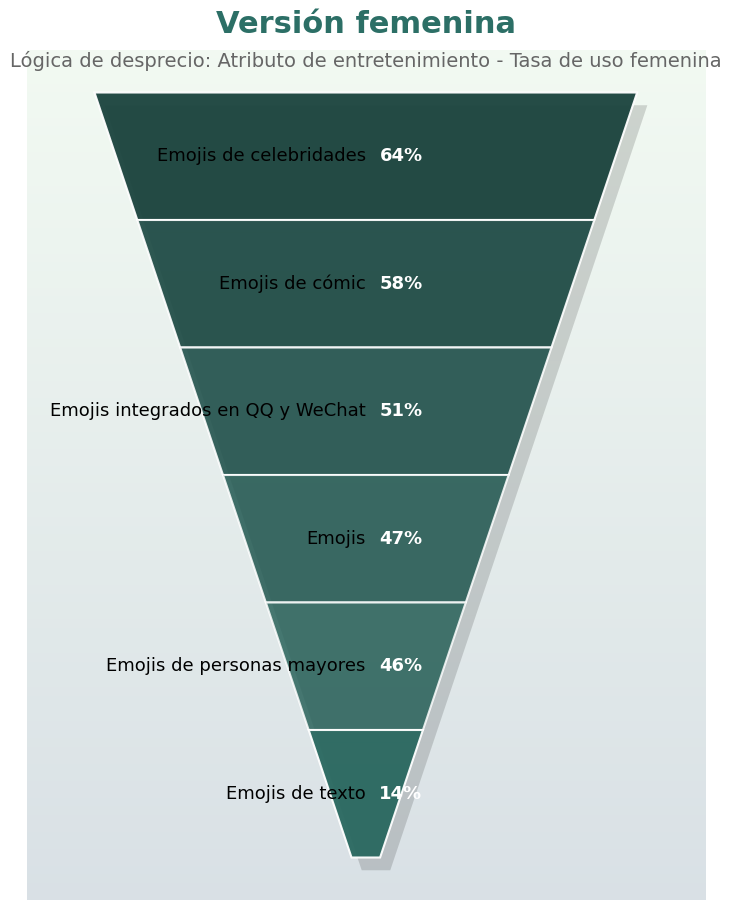

In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import numpy as np

# Etiquetas y datos
labels = [
    "Emojis de celebridades", "Emojis de cómic", "Emojis integrados en QQ y WeChat",
    "Emojis", "Emojis de personas mayores", "Emojis de texto"
]
values = [64, 58, 51, 47, 46, 14]

# Generar serie de colores degradados
def get_gradient_colors(base_color, num_layers, lightness_range=(0.6, 1.0)):
    """Generar colores degradados de oscuro a claro"""
    from matplotlib.colors import LinearSegmentedColormap
    import matplotlib.colors as mcolors

    # Convertir color hexadecimal a RGB
    rgb = mcolors.hex2color(base_color)

    # Crear mapeo de colores degradados
    cmap = LinearSegmentedColormap.from_list(
        f'custom_{base_color}',
        [(rgb[0]*lightness_range[0], rgb[1]*lightness_range[0], rgb[2]*lightness_range[0]),
         (rgb[0]*lightness_range[1], rgb[1]*lightness_range[1], rgb[2]*lightness_range[1])]
    )

    return [cmap(i/num_layers) for i in range(num_layers)]

# Utilizar serie de colores verdes como base
base_color = '#2c6f66'
colors = get_gradient_colors(base_color, len(labels))

# Parámetros del gráfico
num_layers = len(labels)
fig, ax = plt.subplots(figsize=(8, 10))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

# Coordenadas del vértice inferior
bottom_x = 0.5
bottom_y = 0.05

# Ancho superior (el lado superior del triángulo invertido completo)
top_left = (0.1, 0.95)
top_right = (0.9, 0.95)

# Altura de cada capa (dividida uniformemente)
layer_height = (top_left[1] - bottom_y) / num_layers

# Dibujar el degradado de fondo
gradient_bg = np.zeros((100, 100, 3))
for i in range(100):
    for j in range(100):
        y_norm = i / 100
        # Color de fondo de verde claro a verde aún más claro
        gradient_bg[i, j] = [0.95 - y_norm*0.1, 0.98 - y_norm*0.1, 0.95 - y_norm*0.05]
ax.imshow(gradient_bg, extent=[0, 1, 0, 1], aspect='auto', zorder=0)

# Agregar efecto de sombra
shadow_offset = 0.015
for i in range(num_layers):
    # Coordenadas y superiores e inferiores
    y_top = top_left[1] - i * layer_height
    y_bottom = top_left[1] - (i + 1) * layer_height

    # Calcular las coordenadas x de los límites izquierdo y derecho del triángulo a la altura correspondiente
    x_left_top = top_left[0] + (bottom_x - top_left[0]) * (top_left[1] - y_top) / top_left[1]
    x_right_top = top_right[0] - (top_right[0] - bottom_x) * (top_right[1] - y_top) / top_right[1]
    x_left_bottom = top_left[0] + (bottom_x - top_left[0]) * (top_left[1] - y_bottom) / top_left[1]
    x_right_bottom = top_right[0] - (top_right[0] - bottom_x) * (top_right[1] - y_bottom) / top_right[1]

    # Construir la forma de la sombra
    shadow_points = [
        (x_left_top + shadow_offset, y_top - shadow_offset),
        (x_right_top + shadow_offset, y_top - shadow_offset),
        (x_right_bottom + shadow_offset, y_bottom - shadow_offset),
        (x_left_bottom + shadow_offset, y_bottom - shadow_offset)
    ]
    shadow = Polygon(shadow_points, closed=True, facecolor='black', alpha=0.15, zorder=i+1)
    ax.add_patch(shadow)

# Dibujar el gráfico principal
for i in range(num_layers):
    # Coordenadas y superiores e inferiores
    y_top = top_left[1] - i * layer_height
    y_bottom = top_left[1] - (i + 1) * layer_height

    # Calcular las coordenadas x de los límites izquierdo y derecho del triángulo a la altura correspondiente
    x_left_top = top_left[0] + (bottom_x - top_left[0]) * (top_left[1] - y_top) / top_left[1]
    x_right_top = top_right[0] - (top_right[0] - bottom_x) * (top_right[1] - y_top) / top_right[1]
    x_left_bottom = top_left[0] + (bottom_x - top_left[0]) * (top_left[1] - y_bottom) / top_left[1]
    x_right_bottom = top_right[0] - (top_right[0] - bottom_x) * (top_right[1] - y_bottom) / top_right[1]

    # Construir la forma de la franja trapezoidal/triangular
    points = [
        (x_left_top, y_top),
        (x_right_top, y_top),
        (x_right_bottom, y_bottom),
        (x_left_bottom, y_bottom)
    ]

    # Agregar un ligero cambio de transparencia para que la parte inferior sea más obvia
    alpha = 0.95 - i * 0.03 if i < num_layers - 1 else 0.95
    tri = Polygon(points, closed=True, facecolor=colors[i], edgecolor='white', linewidth=1.5, alpha=alpha, zorder=i+2)
    ax.add_patch(tri)

    # Escribir texto en el centro de cada capa
    y_text = (y_top + y_bottom) / 2
    ax.text(0.5, y_text, f"{labels[i]}",
            color='black', ha='right', va='center', fontsize=13, fontweight='medium',
            transform=ax.transAxes, zorder=10)

    # Agregar etiquetas de porcentaje
    ax.text(0.52, y_text, f"{values[i]}%",
            color='white', ha='left', va='center', fontsize=13, fontweight='bold',
            transform=ax.transAxes, zorder=10)

# Agregar nuevo texto relacionado con el título, ajustar el título y el subtítulo según sea necesario
plt.text(0.5, 1.02, "Versión femenina", ha='center', fontsize=22, weight='bold', color=base_color, transform=ax.transAxes)
plt.text(0.5, 0.98, "Lógica de desprecio: Atributo de entretenimiento - Tasa de uso femenina", ha='center', fontsize=14, color='#666666', transform=ax.transAxes)

# Ajustar el diseño
plt.tight_layout()
plt.subplots_adjust(top=0.9, bottom=0.05)
plt.show()

# 文件: chart_24_2.py

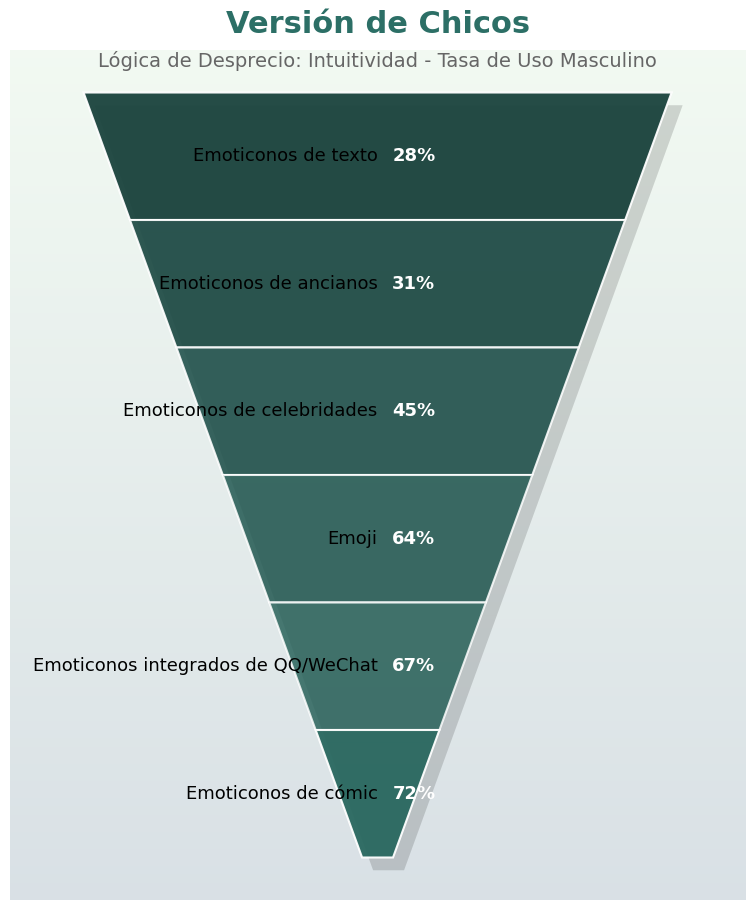

In [2]:
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import numpy as np

# Etiquetas y datos (correspondientes a la versión de los chicos de la lógica de desprecio: Intuitividad - Tasa de uso masculino)
labels = [
    "Emoticonos de texto", "Emoticonos de ancianos", "Emoticonos de celebridades",
    "Emoji", "Emoticonos integrados de QQ/WeChat", "Emoticonos de cómic"
]
values = [28, 31, 45, 64, 67, 72]

# Generar un esquema de colores degradados
def get_gradient_colors(base_color, num_layers, lightness_range=(0.6, 1.0)):
    """Generar un degradado de oscuro a claro"""
    from matplotlib.colors import LinearSegmentedColormap
    import matplotlib.colors as mcolors

    # Convertir color hexadecimal a RGB
    rgb = mcolors.hex2color(base_color)

    # Crear un mapa de colores degradado
    cmap = LinearSegmentedColormap.from_list(
        f'custom_{base_color}',
        [(rgb[0]*lightness_range[0], rgb[1]*lightness_range[0], rgb[2]*lightness_range[0]),
         (rgb[0]*lightness_range[1], rgb[1]*lightness_range[1], rgb[2]*lightness_range[1])]
    )

    return [cmap(i/num_layers) for i in range(num_layers)]

# Usar el esquema de color verde como base
base_color = '#2c6f66'
colors = get_gradient_colors(base_color, len(labels))

# Parámetros del gráfico
num_layers = len(labels)
fig, ax = plt.subplots(figsize=(8, 10))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

# Coordenadas del vértice inferior
bottom_x = 0.5
bottom_y = 0.05

# Ancho superior (el lado superior del triángulo invertido completo)
top_left = (0.1, 0.95)
top_right = (0.9, 0.95)

# Altura de cada capa (dividida uniformemente)
layer_height = (top_left[1] - bottom_y) / num_layers

# Dibujar el degradado de fondo
gradient_bg = np.zeros((100, 100, 3))
for i in range(100):
    for j in range(100):
        y_norm = i / 100
        # El color de fondo cambia de verde claro a verde aún más claro
        gradient_bg[i, j] = [0.95 - y_norm*0.1, 0.98 - y_norm*0.1, 0.95 - y_norm*0.05]
ax.imshow(gradient_bg, extent=[0, 1, 0, 1], aspect='auto', zorder=0)

# Agregar efecto de sombra
shadow_offset = 0.015
for i in range(num_layers):
    # Coordenadas y superiores e inferiores
    y_top = top_left[1] - i * layer_height
    y_bottom = top_left[1] - (i + 1) * layer_height

    # Calcular las coordenadas x de los límites izquierdo y derecho del triángulo a la altura correspondiente
    x_left_top = top_left[0] + (bottom_x - top_left[0]) * (top_left[1] - y_top) / top_left[1]
    x_right_top = top_right[0] - (top_right[0] - bottom_x) * (top_right[1] - y_top) / top_right[1]
    x_left_bottom = top_left[0] + (bottom_x - top_left[0]) * (top_left[1] - y_bottom) / top_left[1]
    x_right_bottom = top_right[0] - (top_right[0] - bottom_x) * (top_right[1] - y_bottom) / top_right[1]

    # Construir la forma de la sombra
    shadow_points = [
        (x_left_top + shadow_offset, y_top - shadow_offset),
        (x_right_top + shadow_offset, y_top - shadow_offset),
        (x_right_bottom + shadow_offset, y_bottom - shadow_offset),
        (x_left_bottom + shadow_offset, y_bottom - shadow_offset)
    ]
    shadow = Polygon(shadow_points, closed=True, facecolor='black', alpha=0.15, zorder=i+1)
    ax.add_patch(shadow)

# Dibujar el gráfico principal
for i in range(num_layers):
    # Coordenadas y superiores e inferiores
    y_top = top_left[1] - i * layer_height
    y_bottom = top_left[1] - (i + 1) * layer_height

    # Calcular las coordenadas x de los límites izquierdo y derecho del triángulo a la altura correspondiente
    x_left_top = top_left[0] + (bottom_x - top_left[0]) * (top_left[1] - y_top) / top_left[1]
    x_right_top = top_right[0] - (top_right[0] - bottom_x) * (top_right[1] - y_top) / top_right[1]
    x_left_bottom = top_left[0] + (bottom_x - top_left[0]) * (top_left[1] - y_bottom) / top_left[1]
    x_right_bottom = top_right[0] - (top_right[0] - bottom_x) * (top_right[1] - y_bottom) / top_right[1]

    # Construir la forma de la franja trapezoidal/triangular
    points = [
        (x_left_top, y_top),
        (x_right_top, y_top),
        (x_right_bottom, y_bottom),
        (x_left_bottom, y_bottom)
    ]

    # Agregar un ligero cambio de transparencia para que la parte inferior sea más obvia
    alpha = 0.95 - i * 0.03 if i < num_layers - 1 else 0.95
    tri = Polygon(points, closed=True, facecolor=colors[i], edgecolor='white', linewidth=1.5, alpha=alpha, zorder=i+2)
    ax.add_patch(tri)

    # Escribir texto en el centro de cada capa
    y_text = (y_top + y_bottom) / 2
    ax.text(0.5, y_text, f"{labels[i]}",
            color='black', ha='right', va='center', fontsize=13, fontweight='medium',
            transform=ax.transAxes, zorder=10)

    # Agregar etiquetas de porcentaje
    ax.text(0.52, y_text, f"{values[i]}%",
            color='white', ha='left', va='center', fontsize=13, fontweight='bold',
            transform=ax.transAxes, zorder=10)

# Agregar nuevo texto relacionado con el título, ajustar el título y el subtítulo según los requisitos de la versión de los chicos
plt.text(0.5, 1.02, "Versión de Chicos", ha='center', fontsize=22, weight='bold', color=base_color, transform=ax.transAxes)
plt.text(0.5, 0.98, "Lógica de Desprecio: Intuitividad - Tasa de Uso Masculino", ha='center', fontsize=14, color='#666666', transform=ax.transAxes)

# Ajustar el diseño
plt.tight_layout()
plt.subplots_adjust(top=0.9, bottom=0.05)
plt.show()

# 文件: chart_24_3.py

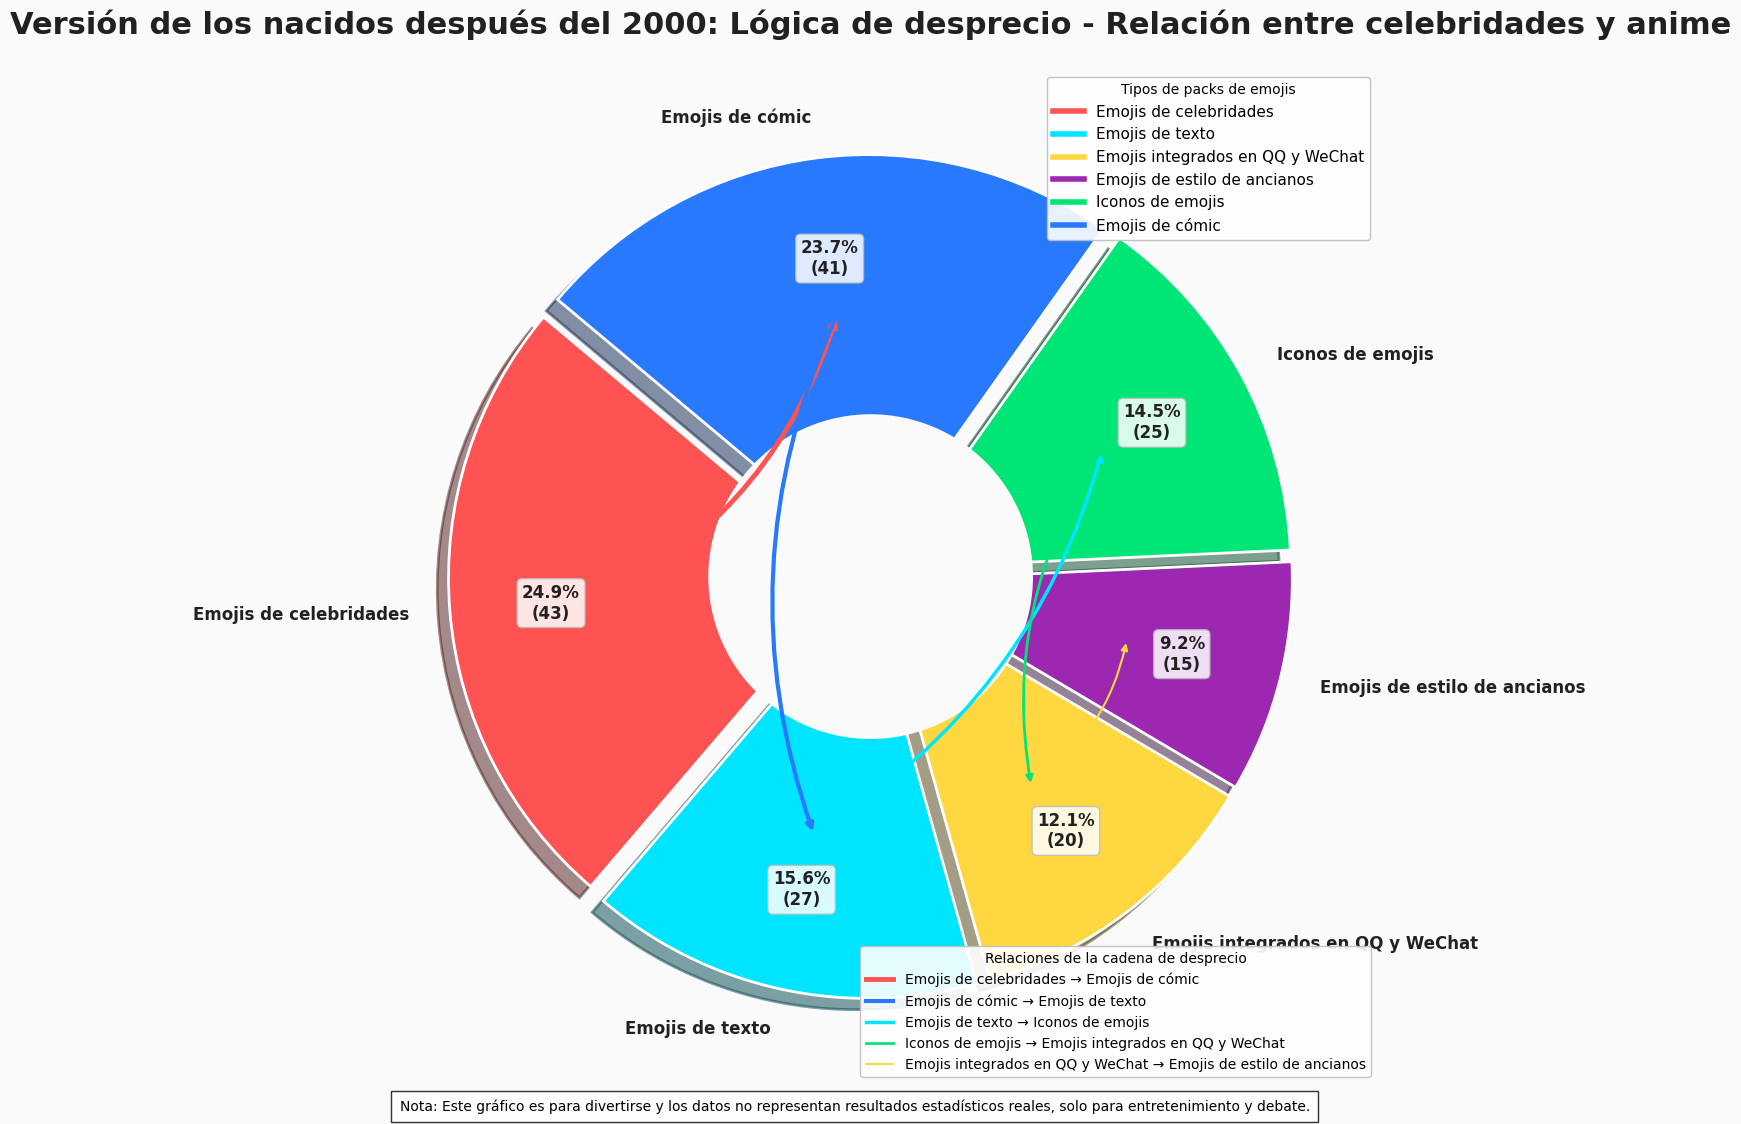

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# Esquema de colores de los packs de emojis (correspondiendo estrictamente a los tipos)
mapa_colores = {
    'Emojis de celebridades': '#FF5252',
    'Emojis de texto': '#00E5FF',
    'Emojis integrados en QQ y WeChat': '#FFD740',
    'Emojis de estilo de ancianos': '#9C27B0',
    'Iconos de emojis': '#00E676',
    'Emojis de cómic': '#2979FF',
}

# Definición de datos (mantener la lógica original)
categorias = ['Emojis de celebridades', 'Emojis de texto', 'Emojis integrados en QQ y WeChat', 
              'Emojis de estilo de ancianos', 'Iconos de emojis', 'Emojis de cómic']
porcentajes = [43, 27, 21, 16, 25, 41]

# Relaciones de la cadena de desprecio (correspondencia clara de tipos para facilitar el mapeo de colores)
conexiones = [
    ('Emojis de celebridades', 'Emojis de cómic', 3.5),   # Celebridades → Cómic
    ('Emojis de cómic', 'Emojis de texto', 3),    # Cómic → Texto
    ('Emojis de texto', 'Iconos de emojis', 2.5),       # Texto → Emoji
    ('Iconos de emojis', 'Emojis integrados en QQ y WeChat', 2),    # Emoji → QQ
    ('Emojis integrados en QQ y WeChat', 'Emojis de estilo de ancianos', 1.5),  # QQ → Ancianos
]

# Crear un lienzo y configuraciones básicas
fig, ax = plt.subplots(figsize=(14, 12), facecolor='#FAFAFA')
ax.set_facecolor('#FAFAFA')
ax.grid(True, linestyle='--', alpha=0.3, color='#EEEEEE')

# Dibujar un gráfico circular (mejorar la sombra y el borde)
porciones, textos, textos_porcentaje = ax.pie(
    porcentajes, 
    labels=categorias, 
    autopct=lambda p: f'{p:.1f}%\n({int(p * sum(porcentajes) / 100)})',
    colors=[mapa_colores[c] for c in categorias],
    startangle=140,
    pctdistance=0.75,
    explode=[0.04] * 6,
    shadow=True,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2, 'antialiased': True},
    textprops={'fontsize': 12, 'weight': 'bold', 'color': '#212121'}
)

# Máscara blanca en el centro (mejorar la sensación de jerarquía)
circulo_centro = plt.Circle((0, 0), 0.4, color='#FAFAFA', linewidth=0, zorder=1)
ax.add_artist(circulo_centro)

# Optimizar el estilo de las etiquetas de porcentaje (con un cuadro de fondo blanco)
for a in textos_porcentaje:
    a.set_bbox(dict(boxstyle="round,pad=0.3", fc="white", ec="#BDBDBD", alpha=0.85))

# Establecer el título
ax.set_title('Versión de los nacidos después del 2000: Lógica de desprecio - Relación entre celebridades y anime', 
             fontsize=22, 
             fontweight='bold', 
             color='#212121',
             pad=25)

# Dibujar flechas de la cadena de desprecio (el color corresponde estrictamente al color principal del pack de emojis)
for categoria_inicio, categoria_fin, grosor in conexiones:
    # Encontrar el ángulo del sector correspondiente
    porcion_inicio = [w for w, l in zip(porciones, categorias) if l == categoria_inicio][0]
    porcion_fin = [w for w, l in zip(porciones, categorias) if l == categoria_fin][0]
    
    angulo_inicio = (porcion_inicio.theta2 + porcion_inicio.theta1) / 2
    angulo_fin = (porcion_fin.theta2 + porcion_fin.theta1) / 2
    
    # Calcular coordenadas (radio unificado para evitar confusión)
    radio = 0.65
    inicio_x = np.cos(np.radians(angulo_inicio)) * radio
    inicio_y = np.sin(np.radians(angulo_inicio)) * radio
    fin_x = np.cos(np.radians(angulo_fin)) * radio
    fin_y = np.sin(np.radians(angulo_fin)) * radio
    
    # Dibujar una flecha (color único, consistente con el color del pack de emojis de inicio)
    ax.annotate(
        '', 
        xy=(fin_x, fin_y), 
        xytext=(inicio_x, inicio_y),
        arrowprops=dict(
            arrowstyle='-|>', 
            color=mapa_colores[categoria_inicio],  # Usar el color del tipo de inicio
            lw=grosor,
            connectionstyle="arc3,rad=0.2"
        )
    )

# Construir una leyenda (dividida en dos grupos: tipos + relaciones)
leyenda_tipo = [
    Line2D([0], [0], color=mapa_colores[c], lw=4, label=c) 
    for c in categorias
]

leyenda_flecha = [
    Line2D([0], [0], color=mapa_colores[inicio], lw=grosor, label=f'{inicio} → {fin}') 
    for inicio, fin, grosor in conexiones
]

# Combinar las leyendas (tipos primero, luego relaciones)
leyenda1 = ax.legend(
    handles=leyenda_tipo, 
    loc='upper right', 
    title="Tipos de packs de emojis", 
    fontsize=11, 
    frameon=True,
    framealpha=0.9, 
    facecolor='white', 
    edgecolor='#BDBDBD'
)
ax.add_artist(leyenda1)

ax.legend(
    handles=leyenda_flecha, 
    loc='lower right', 
    title="Relaciones de la cadena de desprecio", 
    fontsize=10, 
    frameon=True,
    framealpha=0.9, 
    facecolor='white', 
    edgecolor='#BDBDBD'
)

# Nota al pie
plt.figtext(
    0.15, 0.02, 
    "Nota: Este gráfico es para divertirse y los datos no representan resultados estadísticos reales, solo para entretenimiento y debate.", 
    ha="left", 
    fontsize=10, 
    bbox={"facecolor":"white", "alpha":0.8, "pad":6}
)

# Ajustar el diseño
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 文件: chart_24_4.py

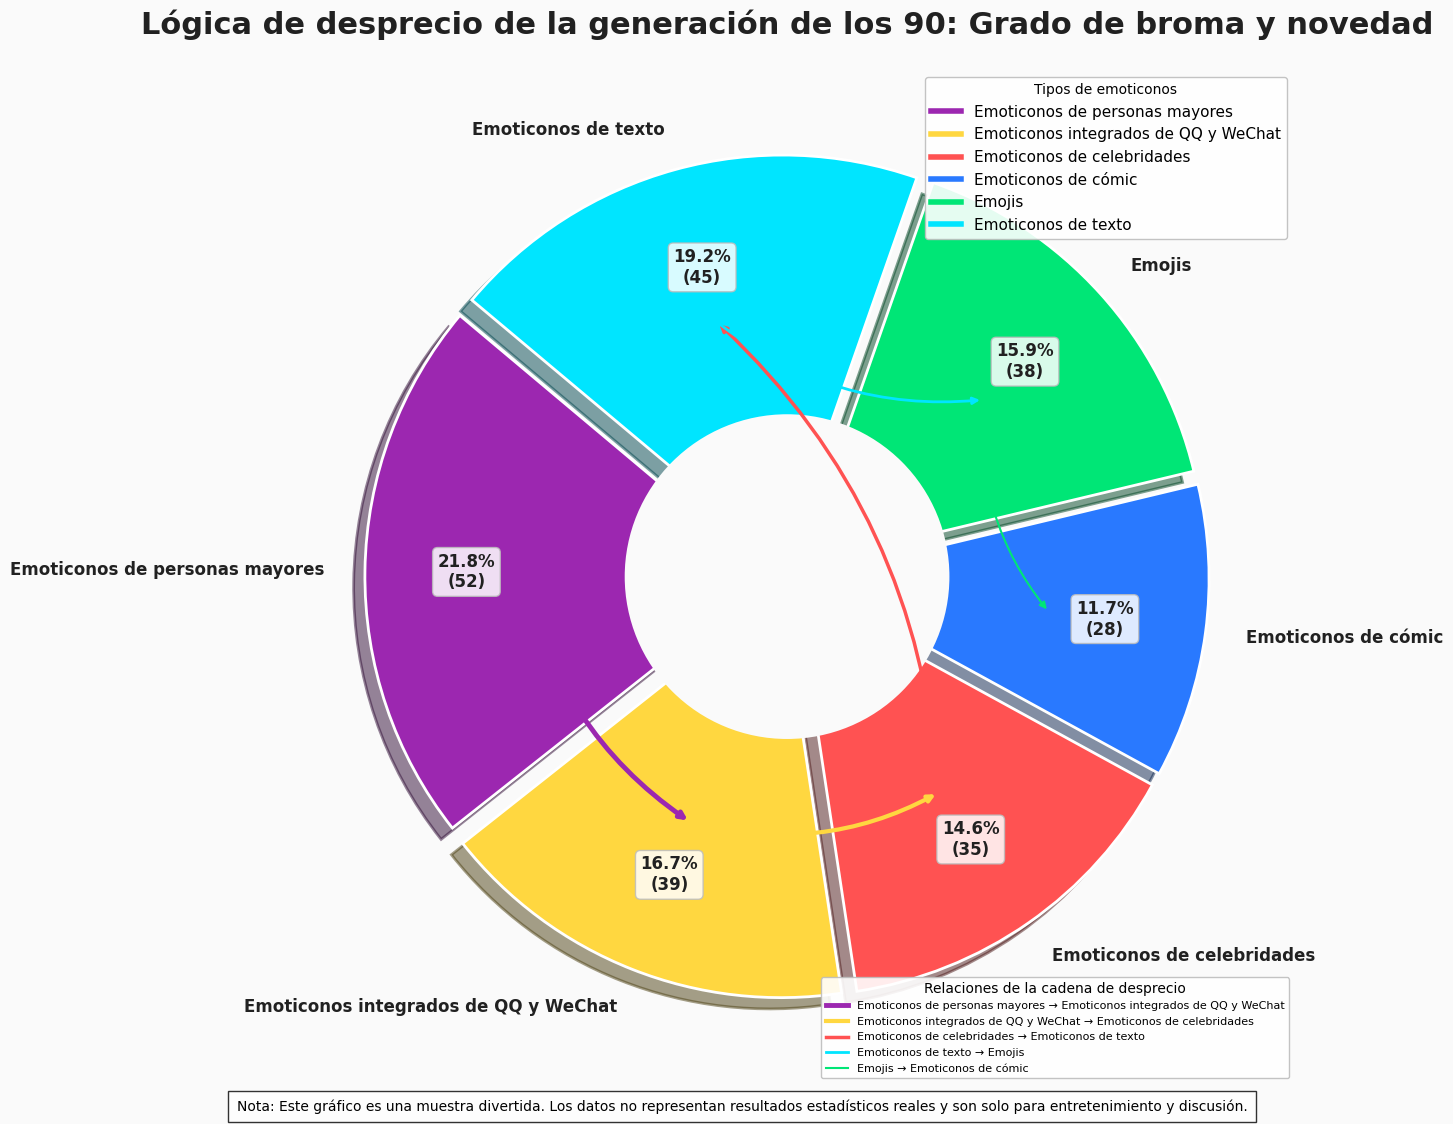

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# Esquema de colores de emoticonos (estrictamente correspondiente a los tipos)
mapa_de_colores = {
    'Emoticonos de celebridades': '#FF5252',
    'Emoticonos de texto': '#00E5FF',
    'Emoticonos integrados de QQ y WeChat': '#FFD740',
    'Emoticonos de personas mayores': '#9C27B0',
    'Emojis': '#00E676',
    'Emoticonos de cómic': '#2979FF',
}

# Definición de datos (mantener la lógica original)
categorias = ['Emoticonos de personas mayores', 'Emoticonos integrados de QQ y WeChat', 'Emoticonos de celebridades',
              'Emoticonos de cómic', 'Emojis', 'Emoticonos de texto']
porcentajes = [52, 40, 35, 28, 38, 46]

# Relaciones de la cadena de desprecio (claramente correspondientes a los tipos para el mapeo de colores)
conexiones = [
    ('Emoticonos de personas mayores', 'Emoticonos integrados de QQ y WeChat', 3.5),  # Personas mayores → QQ y WeChat
    ('Emoticonos integrados de QQ y WeChat', 'Emoticonos de celebridades', 3),  # QQ y WeChat → Celebridades
    ('Emoticonos de celebridades', 'Emoticonos de texto', 2.5),  # Celebridades → Texto
    ('Emoticonos de texto', 'Emojis', 2),  # Texto → Emojis
    ('Emojis', 'Emoticonos de cómic', 1.5),  # Emojis → Cómic
]

# Crear un lienzo y configuraciones básicas
fig, ax = plt.subplots(figsize=(14, 12), facecolor='#FAFAFA')
ax.set_facecolor('#FAFAFA')
ax.grid(True, linestyle='--', alpha=0.3, color='#EEEEEE')

# Dibujar un gráfico de pastel (mejorar la sombra y el borde)
porciones, textos, textos_porcentaje = ax.pie(
    porcentajes,
    labels=categorias,
    autopct=lambda p: f'{p:.1f}%\n({int(p * sum(porcentajes) / 100)})',
    colors=[mapa_de_colores[c] for c in categorias],
    startangle=140,
    pctdistance=0.75,
    explode=[0.04] * 6,
    shadow=True,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2, 'antialiased': True},
    textprops={'fontsize': 12, 'weight': 'bold', 'color': '#212121'}
)

# Máscara blanca en el centro (mejorar la sensación de jerarquía)
circulo_centro = plt.Circle((0, 0), 0.4, color='#FAFAFA', linewidth=0, zorder=1)
ax.add_artist(circulo_centro)

# Optimizar el estilo de las etiquetas de porcentaje (con un cuadro de fondo blanco)
for a in textos_porcentaje:
    a.set_bbox(dict(boxstyle="round,pad=0.3", fc="white", ec="#BDBDBD", alpha=0.85))

# Establecer el título
ax.set_title('Lógica de desprecio de la generación de los 90: Grado de broma y novedad',
             fontsize=22,
             fontweight='bold',
             color='#212121',
             pad=25)

# Dibujar flechas de la cadena de desprecio (colores estrictamente correspondientes al color principal de los emoticonos)
for categoria_inicio, categoria_fin, peso in conexiones:
    # Encontrar el ángulo del sector correspondiente
    porcion_inicio = [w for w, l in zip(porciones, categorias) if l == categoria_inicio][0]
    porcion_fin = [w for w, l in zip(porciones, categorias) if l == categoria_fin][0]

    angulo_inicio = (porcion_inicio.theta2 + porcion_inicio.theta1) / 2
    angulo_fin = (porcion_fin.theta2 + porcion_fin.theta1) / 2

    # Calcular coordenadas (unificar el radio para evitar confusiones)
    radio = 0.65
    inicio_x = np.cos(np.radians(angulo_inicio)) * radio
    inicio_y = np.sin(np.radians(angulo_inicio)) * radio
    fin_x = np.cos(np.radians(angulo_fin)) * radio
    fin_y = np.sin(np.radians(angulo_fin)) * radio

    # Dibujar una flecha (color único, consistente con el color del emoticono de inicio)
    ax.annotate(
        '',
        xy=(fin_x, fin_y),
        xytext=(inicio_x, inicio_y),
        arrowprops=dict(
            arrowstyle='-|>',
            color=mapa_de_colores[categoria_inicio],  # Usar el color del tipo de inicio
            lw=peso,
            connectionstyle="arc3,rad=0.2"
        )
    )

# Construir la leyenda (dividida en dos grupos: tipos + relaciones)
leyenda_tipo = [
    Line2D([0], [0], color=mapa_de_colores[c], lw=4, label=c)
    for c in categorias
]

leyenda_flecha = [
    Line2D([0], [0], color=mapa_de_colores[inicio], lw=peso, label=f'{inicio} → {fin}')
    for inicio, fin, peso in conexiones
]

# Combinar las leyendas (tipos primero, luego relaciones)
leyenda1 = ax.legend(
    handles=leyenda_tipo,
    loc='upper right',
    title="Tipos de emoticonos",
    fontsize=11,
    frameon=True,
    framealpha=0.9,
    facecolor='white',
    edgecolor='#BDBDBD'
)
ax.add_artist(leyenda1)

ax.legend(
    handles=leyenda_flecha,
    loc='lower right',
    title="Relaciones de la cadena de desprecio",
    fontsize=8,
    frameon=True,
    framealpha=0.9,
    facecolor='white',
    edgecolor='#BDBDBD'
)

# Nota al pie
plt.figtext(
    0.15, 0.02,
    "Nota: Este gráfico es una muestra divertida. Los datos no representan resultados estadísticos reales y son solo para entretenimiento y discusión.",
    ha="left",
    fontsize=10,
    bbox={"facecolor": "white", "alpha": 0.8, "pad": 6}
)

# Ajustar el diseño
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 文件: chart_24_5.py

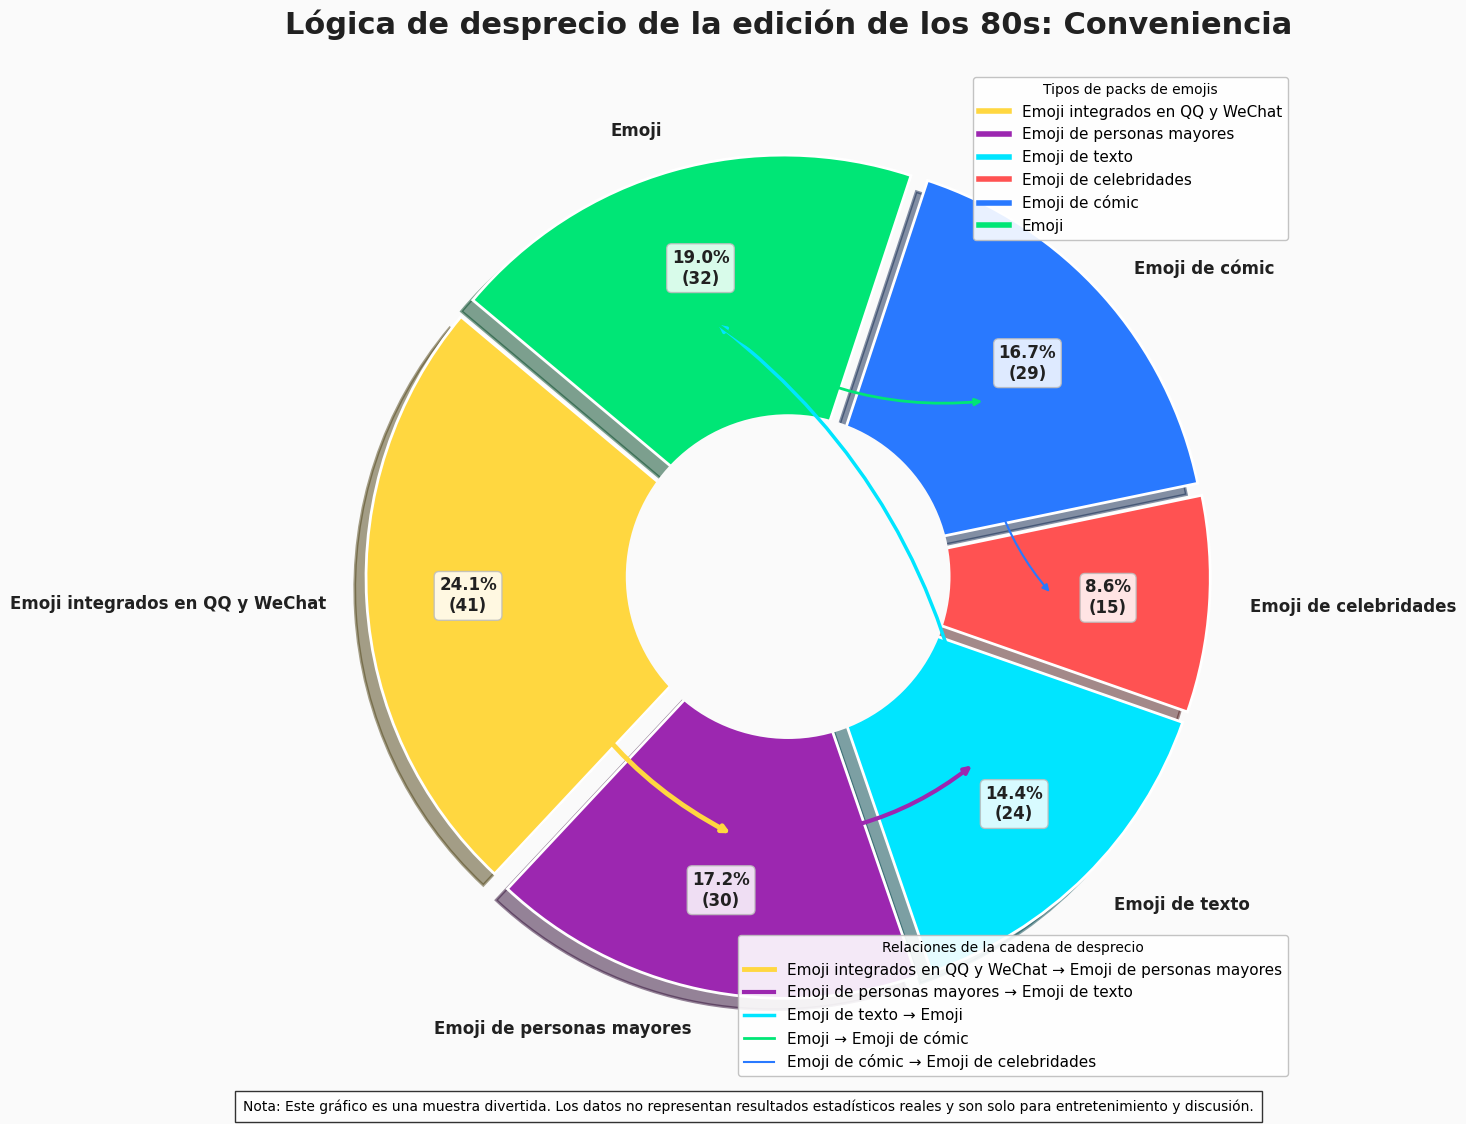

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# Esquema de colores de los packs de emojis (estrictamente correspondiente a los tipos)
mapa_colores = {
    'Emoji de celebridades': '#FF5252',
    'Emoji de texto': '#00E5FF',
    'Emoji integrados en QQ y WeChat': '#FFD740',
    'Emoji de personas mayores': '#9C27B0',
    'Emoji': '#00E676',
    'Emoji de cómic': '#2979FF',
}

# Definición de datos (mantener la lógica original)
categorias = ['Emoji integrados en QQ y WeChat', 'Emoji de personas mayores', 'Emoji de texto',
              'Emoji de celebridades', 'Emoji de cómic', 'Emoji']
porcentajes = [42, 30, 25, 15, 29, 33]

# Relaciones de la cadena de desprecio (claramente correspondientes a los tipos para el mapeo de colores)
conexiones = [
    ('Emoji integrados en QQ y WeChat', 'Emoji de personas mayores', 3.5),  # QQ y WeChat → Personas mayores
    ('Emoji de personas mayores', 'Emoji de texto', 3),       # Personas mayores → Texto
    ('Emoji de texto', 'Emoji', 2.5),           # Texto → Emoji
    ('Emoji', 'Emoji de cómic', 2),            # Emoji → Cómic
    ('Emoji de cómic', 'Emoji de celebridades', 1.5),        # Cómic → Celebridades
]

# Crear el lienzo y configuraciones básicas
fig, ax = plt.subplots(figsize=(14, 12), facecolor='#FAFAFA')
ax.set_facecolor('#FAFAFA')
ax.grid(True, linestyle='--', alpha=0.3, color='#EEEEEE')

# Dibujar el gráfico circular (mejorar la sombra y el borde)
porciones, textos, textos_porcentaje = ax.pie(
    porcentajes,
    labels=categorias,
    autopct=lambda p: f'{p:.1f}%\n({int(p * sum(porcentajes) / 100)})',
    colors=[mapa_colores[c] for c in categorias],
    startangle=140,
    pctdistance=0.75,
    explode=[0.04] * 6,
    shadow=True,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2, 'antialiased': True},
    textprops={'fontsize': 12, 'weight': 'bold', 'color': '#212121'}
)

# Máscara blanca en el centro (mejorar la sensación de jerarquía)
circulo_centro = plt.Circle((0, 0), 0.4, color='#FAFAFA', linewidth=0, zorder=1)
ax.add_artist(circulo_centro)

# Optimizar el estilo de las etiquetas de porcentaje (con un cuadro de fondo blanco)
for a in textos_porcentaje:
    a.set_bbox(dict(boxstyle="round,pad=0.3", fc="white", ec="#BDBDBD", alpha=0.85))

# Establecer el título
ax.set_title('Lógica de desprecio de la edición de los 80s: Conveniencia',
             fontsize=22,
             fontweight='bold',
             color='#212121',
             pad=25)

# Dibujar las flechas de la cadena de desprecio (colores que corresponden estrictamente al color principal del pack de emojis)
for categoria_inicio, categoria_fin, grosor in conexiones:
    # Encontrar el ángulo del sector correspondiente
    porcion_inicio = [w for w, l in zip(porciones, categorias) if l == categoria_inicio][0]
    porcion_fin = [w for w, l in zip(porciones, categorias) if l == categoria_fin][0]

    angulo_inicio = (porcion_inicio.theta2 + porcion_inicio.theta1) / 2
    angulo_fin = (porcion_fin.theta2 + porcion_fin.theta1) / 2

    # Calcular las coordenadas (radio unificado para evitar confusiones)
    radio = 0.65
    inicio_x = np.cos(np.radians(angulo_inicio)) * radio
    inicio_y = np.sin(np.radians(angulo_inicio)) * radio
    fin_x = np.cos(np.radians(angulo_fin)) * radio
    fin_y = np.sin(np.radians(angulo_fin)) * radio

    # Dibujar la flecha (de un solo color, consistente con el color del pack de emojis de inicio)
    ax.annotate(
        '',
        xy=(fin_x, fin_y),
        xytext=(inicio_x, inicio_y),
        arrowprops=dict(
            arrowstyle='-|>',
            color=mapa_colores[categoria_inicio],  # Usar el color del tipo de inicio
            lw=grosor,
            connectionstyle="arc3,rad=0.2"
        )
    )

# Construir la leyenda (dividida en dos grupos: tipos + relaciones)
leyenda_tipo = [
    Line2D([0], [0], color=mapa_colores[c], lw=4, label=c)
    for c in categorias
]

leyenda_flecha = [
    Line2D([0], [0], color=mapa_colores[inicio], lw=grosor, label=f'{inicio} → {fin}')
    for inicio, fin, grosor in conexiones
]

# Combinar las leyendas (tipos primero, luego relaciones)
leyenda1 = ax.legend(
    handles=leyenda_tipo,
    loc='upper right',
    title="Tipos de packs de emojis",
    fontsize=11,
    frameon=True,
    framealpha=0.9,
    facecolor='white',
    edgecolor='#BDBDBD'
)
ax.add_artist(leyenda1)

ax.legend(
    handles=leyenda_flecha,
    loc='lower right',
    title="Relaciones de la cadena de desprecio",
    fontsize=11,
    frameon=True,
    framealpha=0.9,
    facecolor='white',
    edgecolor='#BDBDBD'
)

# Anotación en la parte inferior
plt.figtext(
    0.15, 0.02,
    "Nota: Este gráfico es una muestra divertida. Los datos no representan resultados estadísticos reales y son solo para entretenimiento y discusión.",
    ha="left",
    fontsize=10,
    bbox={"facecolor": "white", "alpha": 0.8, "pad": 6}
)

# Ajustar el diseño
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()